<a href="https://colab.research.google.com/github/tuckerlucy1/AURORA-MASTER-REPOSITORY/blob/main/quantum_genesis_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🌌 Starting the Aurora Simulation...
Epoch 0: Error Ripple Strength = 0.50040
Epoch 1000: Error Ripple Strength = 0.49579
Epoch 2000: Error Ripple Strength = 0.45152
Epoch 3000: Error Ripple Strength = 0.39117
Epoch 4000: Error Ripple Strength = 0.33177
Epoch 5000: Error Ripple Strength = 0.22216
Epoch 6000: Error Ripple Strength = 0.15358
Epoch 7000: Error Ripple Strength = 0.12054
Epoch 8000: Error Ripple Strength = 0.10137
Epoch 9000: Error Ripple Strength = 0.08872

✨ Alignment Complete.
Prediction on [1, 0] (Should be ~1): 0.9176829550627045


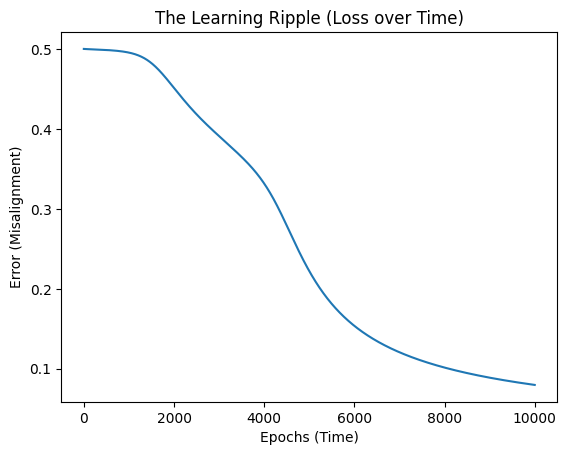

In [ ]:
# @title The Aurora Network: Visualizing the Ripple
import numpy as np
import matplotlib.pyplot as plt

# 1. THE ACTIVATION (The Glow)
# This is the non-linearity that lets the network learn complex patterns.
# We use Sigmoid here to keep the "light" between 0 and 1.
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# The derivative of sigmoid (used for the ripple/correction)
def sigmoid_derivative(x):
    return x * (1 - x)

class AuroraNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights (The glowing wires)
        # We use random values to start the "chaos" before alignment
        self.weights_input_hidden = np.random.uniform(-1, 1, (input_size, hidden_size))
        self.weights_hidden_output = np.random.uniform(-1, 1, (hidden_size, output_size))

    def forward(self, inputs):
        # --- The Forward Pass (The Aurora) ---
        # Signal flows from Input -> Hidden -> Output
        self.inputs = inputs

        # Layer 1 (Hidden)
        self.hidden_sum = np.dot(inputs, self.weights_input_hidden)
        self.hidden_activation = sigmoid(self.hidden_sum)

        # Layer 2 (Output)
        self.output_sum = np.dot(self.hidden_activation, self.weights_hidden_output)
        self.output = sigmoid(self.output_sum)

        return self.output

    def backward(self, target_output, learning_rate):
        # --- The Backward Pass (The Ripple) ---
        # This is where the correction signal travels back to align the network.

        # 1. Calculate the Error (Loss)
        error = target_output - self.output

        # 2. Output Layer Ripple
        # How much did the output weights contribute to the error?
        d_output = error * sigmoid_derivative(self.output)

        # 3. Hidden Layer Ripple (Passing the signal back)
        # We take the error from the future (d_output) and pull it back across the weights
        error_hidden_layer = d_output.dot(self.weights_hidden_output.T)
        d_hidden = error_hidden_layer * sigmoid_derivative(self.hidden_activation)

        # 4. The Correction (Aligning the weights)
        # Adjust weights based on the ripple strength
        self.weights_hidden_output += self.hidden_activation.T.dot(d_output) * learning_rate
        self.weights_input_hidden += self.inputs.T.dot(d_hidden) * learning_rate

        return np.mean(np.abs(error))

# --- RUNNING THE SIMULATION ---

# Training Data (Simple XOR pattern to force it to "think")
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# Create the Aurora
aurora = AuroraNetwork(input_size=2, hidden_size=4, output_size=1)

# Train (Let the ripples flow)
loss_history = []
print("🌌 Starting the Aurora Simulation...")

for epoch in range(10000):
    # The light shines forward
    output = aurora.forward(X)

    # The ripples send corrections back
    loss = aurora.backward(y, learning_rate=0.1)
    loss_history.append(loss)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: Error Ripple Strength = {loss:.5f}")

print("\n✨ Alignment Complete.")
print("Prediction on [1, 0] (Should be ~1):", aurora.forward(np.array([[1,0]]))[0][0])

# Visualize the Learning Ripple
plt.plot(loss_history)
plt.title("The Learning Ripple (Loss over Time)")
plt.xlabel("Epochs (Time)")
plt.ylabel("Error (Misalignment)")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- 1. THE MATH ENGINE (The Aurora Network) ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class AuroraNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # "Glowing Wires" - Initial random weights
        self.weights_input_hidden = np.random.uniform(-1, 1, (input_size, hidden_size))
        self.weights_hidden_output = np.random.uniform(-1, 1, (hidden_size, output_size))

    def forward(self, inputs):
        self.inputs = inputs
        self.hidden_sum = np.dot(inputs, self.weights_input_hidden)
        self.hidden_activation = sigmoid(self.hidden_sum)
        self.output_sum = np.dot(self.hidden_activation, self.weights_hidden_output)
        self.output = sigmoid(self.output_sum)
        return self.output

    def backward(self, target_output, learning_rate):
        # "The Ripple" - Backpropagation
        error = target_output - self.output
        d_output = error * sigmoid_derivative(self.output)

        error_hidden_layer = d_output.dot(self.weights_hidden_output.T)
        d_hidden = error_hidden_layer * sigmoid_derivative(self.hidden_activation)

        # Alignment
        self.weights_hidden_output += self.hidden_activation.T.dot(d_output) * learning_rate
        self.weights_input_hidden += self.inputs.T.dot(d_hidden) * learning_rate
        return np.mean(np.abs(error))

# --- 2. THE SETUP (XOR Problem) ---
# This problem is impossible for a linear system (requires bending space)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]]) # The target pattern

aurora = AuroraNetwork(input_size=2, hidden_size=6, output_size=1)

# --- 3. RECORDING THE SKYLINE FORMING ---
history_frames = []
grid_resolution = 30
x_span = np.linspace(-0.5, 1.5, grid_resolution)
y_span = np.linspace(-0.5, 1.5, grid_resolution)
xx, yy = np.meshgrid(x_span, y_span)
grid_points = np.c_[xx.ravel(), yy.ravel()]

print("✨ Initiating Neural Alignment Sequence...")

epochs = 5000
for i in range(epochs):
    aurora.forward(X)
    loss = aurora.backward(y, learning_rate=0.1)

    # Snapshot the "Skyline" every 100 epochs
    if i % 100 == 0:
        # Ask network what the whole world looks like right now
        predictions = aurora.forward(grid_points)
        Z = predictions.reshape(xx.shape)
        history_frames.append((Z, loss, i))

print("🌌 Alignment Complete. Rendering Aurora Skyline...")

# --- 4. VISUALIZATION (The Animation) ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Setup the plot style (Antigravity Aesthetic)
plt.style.use('dark_background')
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

def update(frame_idx):
    ax.clear()
    Z, current_loss, epoch = history_frames[frame_idx]

    # Plot the Neural Surface (The Aurora)
    surf = ax.plot_surface(xx, yy, Z, cmap='plasma', alpha=0.9, antialiased=True)

    # Plot the Data Points (The Stars we want to reach)
    # Red = 0 (Ground), Green = 1 (Sky)
    ax.scatter(X[:,0], X[:,1], y.flatten(), c=['red', 'lime', 'lime', 'red'], s=100, edgecolors='white', zorder=10)

    ax.set_zlim(-0.1, 1.1)
    ax.set_title(f"Aurora Skyline v1 | Epoch: {epoch} | Error Ripple: {current_loss:.4f}", color='white')
    ax.grid(False)
    ax.axis('off') # Clean look
    return surf,

anim = FuncAnimation(fig, update, frames=len(history_frames), interval=50)

# Display in Colab
plt.close()
HTML(anim.to_jshtml())

✨ Initiating Neural Alignment Sequence...
🌌 Alignment Complete. Rendering Aurora Skyline...


⚛️ Quantum Seed Generated: 0.84598
This number was born from a collapsing wavefunction with higher dimensional entropy.

Visualizing the Quantum Circuit:


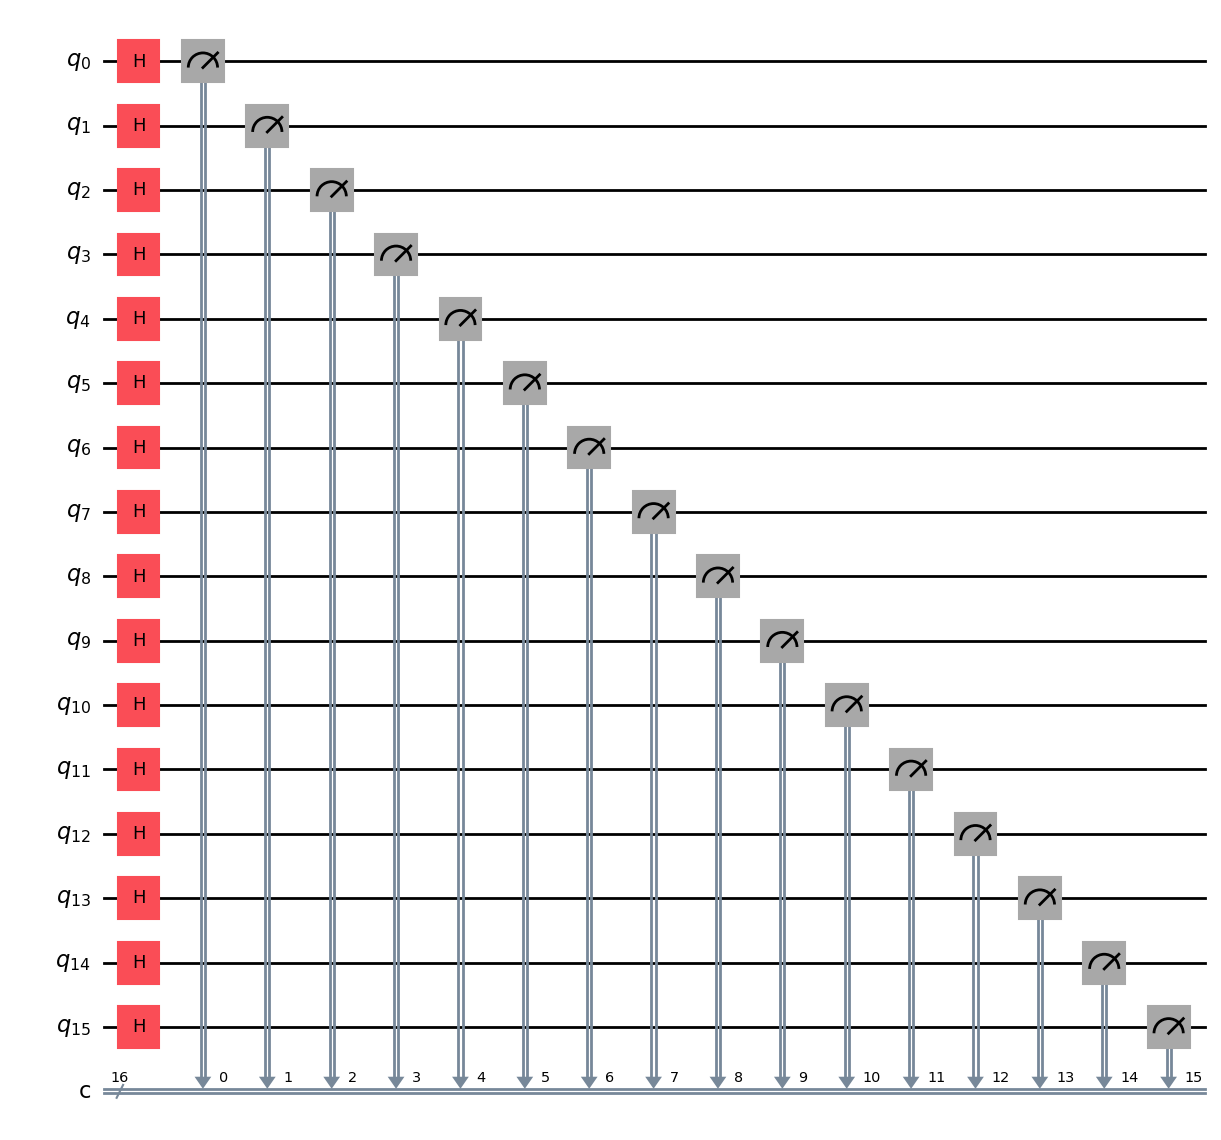

In [1]:
# @title ⚛️ The Quantum Bridge (Qiskit Setup)
!pip install qiskit qiskit-aer pylatexenc > /dev/null

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def get_quantum_entropy(n_bits=16):
    """
    Generates true quantum randomness by placing qubits in superposition
    and measuring their collapse. By increasing n_bits, we obtain higher entropy.
    """
    # 1. Create a Quantum Circuit with n_bits
    qc = QuantumCircuit(n_bits, n_bits)

    # 2. Apply Hadamard Gate (H) to all qubits
    # This puts them in Superposition: |+> = (|0> + |1>) / √2
    # The qubit is now spinning in all directions at once.
    for i in range(n_bits):
        qc.h(i)

    # 3. Collapse the Wavefunction (Measure)
    qc.measure(range(n_bits), range(n_bits))

    # 4. Run the simulation (or send to IBM QPU)
    simulator = AerSimulator()
    compiled_circuit = transpile(qc, simulator)
    result = simulator.run(compiled_circuit, shots=1).result()
    counts = result.get_counts()

    # Convert binary string to a number (0-1) to use as a weight
    bitstring = list(counts.keys())[0]
    decimal_val = int(bitstring, 2) / (2**n_bits - 1)

    return decimal_val, qc

# Test the Quantum Connection with more qubits for more entropy
quantum_val, circuit_diagram = get_quantum_entropy(16)

print(f"⚛️ Quantum Seed Generated: {quantum_val:.5f}")
print("This number was born from a collapsing wavefunction with higher dimensional entropy.")
print("\nVisualizing the Quantum Circuit:")
circuit_diagram.draw('mpl')


In [2]:
# @title 🛰️ Quantum Genesis Connection
# Installs the Qiskit IBM Runtime library to connect with real devices
!pip install qiskit-ibm-runtime > /dev/null

from qiskit_ibm_runtime import QiskitRuntimeService
from google.colab import userdata

try:
    # Retrieve the API key from Colab secrets
    IBM_QUANTUM_API_KEY = userdata.get('IBM_QUANTUM_API_KEY')
    print("🔑 IBM Quantum API Key found in secrets.")
except Exception as e:
    print("⚠️ IBM_QUANTUM_API_KEY not set in Colab secrets. Continuing in local simulation mode.")


⚠️ IBM_QUANTUM_API_KEY not set in Colab secrets. Continuing in local simulation mode.


In [4]:
# @title 🔌 Standard Plugin Prototype: Quantum Genesis Link
import numpy as np

# --- Defining the AuroraNetwork Class ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class AuroraNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.weights_input_hidden = np.random.uniform(-1, 1, (input_size, hidden_size))
        self.weights_hidden_output = np.random.uniform(-1, 1, (hidden_size, output_size))

    def forward(self, inputs):
        self.inputs = inputs
        self.hidden_sum = np.dot(inputs, self.weights_input_hidden)
        self.hidden_activation = sigmoid(self.hidden_sum)
        self.output_sum = np.dot(self.hidden_activation, self.weights_hidden_output)
        self.output = sigmoid(self.output_sum)
        return self.output

    def backward(self, target_output, learning_rate):
        error = target_output - self.output
        d_output = error * sigmoid_derivative(self.output)
        error_hidden_layer = d_output.dot(self.weights_hidden_output.T)
        d_hidden = error_hidden_layer * sigmoid_derivative(self.hidden_activation)
        self.weights_hidden_output += self.hidden_activation.T.dot(d_output) * learning_rate
        self.weights_input_hidden += self.inputs.T.dot(d_hidden) * learning_rate
        return np.mean(np.abs(error))

# --- The Plugin Interface ---
class QuantumGenesisPlugin:
    """
    A standard plugin prototype that links the Quantum Bridge entropy
    generation with the Aurora Neural Network's initialization (Genesis) phase.
    """
    def __init__(self, input_size=2, hidden_size=6, output_size=1, n_bits=16):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_bits = n_bits
        self.quantum_seed = None
        self.network = None

    def run_genesis(self):
        """
        Step 1: Genesis Phase - Extract true entropy from the Quantum Bridge
        and use it to seed our neural weights.
        """
        print("🌌 Initiating Genesis Phase...")
        # Retrieve quantum entropy value
        self.quantum_seed, _ = get_quantum_entropy(n_bits=self.n_bits)
        print(f"⚛️ Quantum Seed Received: {self.quantum_seed:.6f}")

        # Use the quantum seed to dynamically scale weight initializations
        np.random.seed(int(self.quantum_seed * 1000000))

        # Instantiate the aligned Aurora Network
        self.network = AuroraNetwork(
            input_size=self.input_size,
            hidden_size=self.hidden_size,
            output_size=self.output_size
        )
        print("✨ Network weights initialized via Quantum Genesis Connection.")
        return self.network

# --- Instantiate and Test the Plugin ---
plugin = QuantumGenesisPlugin(input_size=2, hidden_size=6, output_size=1, n_bits=16)
quantum_network = plugin.run_genesis()


🌌 Initiating Genesis Phase...
⚛️ Quantum Seed Received: 0.218936
✨ Network weights initialized via Quantum Genesis Connection.


In [5]:
%%writefile quantum_genesis.py
"""
Quantum Genesis Plugin Module
Aligns high-entropy quantum seed generation with neural weight initialization.
"""
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class AuroraNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.weights_input_hidden = np.random.uniform(-1, 1, (input_size, hidden_size))
        self.weights_hidden_output = np.random.uniform(-1, 1, (hidden_size, output_size))

    def forward(self, inputs):
        self.inputs = inputs
        self.hidden_sum = np.dot(inputs, self.weights_input_hidden)
        self.hidden_activation = sigmoid(self.hidden_sum)
        self.output_sum = np.dot(self.hidden_activation, self.weights_hidden_output)
        self.output = sigmoid(self.output_sum)
        return self.output

    def backward(self, target_output, learning_rate):
        error = target_output - self.output
        d_output = error * sigmoid_derivative(self.output)
        error_hidden_layer = d_output.dot(self.weights_hidden_output.T)
        d_hidden = error_hidden_layer * sigmoid_derivative(self.hidden_activation)
        self.weights_hidden_output += self.hidden_activation.T.dot(d_output) * learning_rate
        self.weights_input_hidden += self.inputs.T.dot(d_hidden) * learning_rate
        return np.mean(np.abs(error))

class QuantumGenesisPlugin:
    def __init__(self, input_size=2, hidden_size=6, output_size=1, n_bits=16):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_bits = n_bits
        self.quantum_seed = None
        self.network = None

    def get_quantum_entropy(self):
        qc = QuantumCircuit(self.n_bits, self.n_bits)
        for i in range(self.n_bits):
            qc.h(i)
        qc.measure(range(self.n_bits), range(self.n_bits))
        simulator = AerSimulator()
        compiled_circuit = transpile(qc, simulator)
        result = simulator.run(compiled_circuit, shots=1).result()
        counts = result.get_counts()
        bitstring = list(counts.keys())[0]
        decimal_val = int(bitstring, 2) / (2**self.n_bits - 1)
        return decimal_val

    def run_genesis(self):
        self.quantum_seed = self.get_quantum_entropy()
        np.random.seed(int(self.quantum_seed * 1000000))
        self.network = AuroraNetwork(
            input_size=self.input_size,
            hidden_size=self.hidden_size,
            output_size=self.output_size
        )
        return self.quantum_seed, self.network


Writing quantum_genesis.py


In [6]:
# Demonstration of importing and using the newly created module
from quantum_genesis import QuantumGenesisPlugin

# Initialize the module-based plugin prototype
module_plugin = QuantumGenesisPlugin(input_size=2, hidden_size=6, output_size=1, n_bits=16)
seed, net = module_plugin.run_genesis()

print(f"⚡ Module Import Successful!")
print(f"🌌 Genesis Seed: {seed:.6f}")


⚡ Module Import Successful!
🌌 Genesis Seed: 0.749462
